# 01 — Data Exploration

**Goal:** Understand the raw collected data — its structure, quality, and quirks — before any cleaning or transformation.


In [535]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Load Raw JSON Files

Each article is stored as a separate `.json` file under `data/raw/<date>/`.
We walk through all date folders and load every article into a flat list, then convert to a DataFrame.

In [536]:
DATA_DIR = "../data/raw"

records = []
for date_folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, date_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            filepath = os.path.join(folder_path, filename)
            with open(filepath, encoding="utf-8") as f:
                records.append(json.load(f))

df = pd.DataFrame(records)
df["published_at_dt"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
print(f"Total articles loaded: {len(df)}")

Total articles loaded: 45932


## 2. Basic Structure Overview

In [537]:
df.head(3)

,source,title,url,published_at,summary,full_text,fetched_at,published_at_dt
0,segabg,Правят се важни промени при шофьорските курсове,https://www.segabg.com/hot/category-consult/pr...,2026-03-10T04:05:33+00:00,Министерство на транспорта прави поредни и то ...,Министерство на транспорта прави поредни и то ...,2026-05-04T19:45:07.876366+00:00,2026-03-10 04:05:33+00:00
1,segabg,МВР променя правилата за колите на починалите,https://www.segabg.com/hot/category-consult/mv...,2026-03-31T17:26:59+00:00,"МВР предупреди, че от от 31 март т. г. започва...","МВР предупреди, че от от 31 март т.г. започва ...",2026-05-04T19:45:07.876356+00:00,2026-03-31 17:26:59+00:00
2,segabg,Сделките с имоти драстично спаднаха през първо...,https://www.segabg.com/hot/sdelkite-imoti-dras...,2026-04-12T03:24:43+00:00,Прогнозите за охлаждане на пазара на недвижими...,Прогнозите за охлаждане на пазара на недвижими...,2026-05-04T19:45:07.876310+00:00,2026-04-12 03:24:43+00:00


In [538]:
print(f"Shape: {df.shape}")

Shape: (45932, 8)


In [539]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['source', 'title', 'url', 'published_at', 'summary', 'full_text', 'fetched_at', 'published_at_dt']


In [540]:
print(f"\nData types:\n{df.dtypes}")


Data types:
source                             str
title                              str
url                                str
published_at                       str
summary                            str
full_text                          str
fetched_at                         str
published_at_dt    datetime64[us, UTC]
dtype: object


## 3. Articles per Source

In [541]:
source_counts = df["source"].value_counts().sort_values(ascending=False)
source_counts

source
24chasa         9978
monitor         9450
fakti           5915
actualno        5902
nova            3875
bta             3179
standartnews    2610
vesti           2006
segabg          1187
banker           705
blitz            531
economic         308
dnevnik          256
capital           30
Name: count, dtype: int64

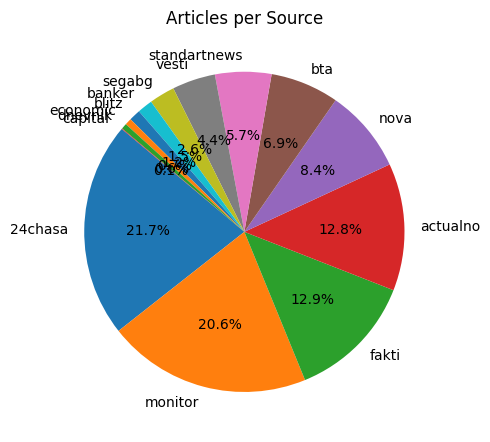

In [542]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    source_counts.values,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=140,
)
ax.set_title("Articles per Source")
plt.tight_layout()
plt.show()

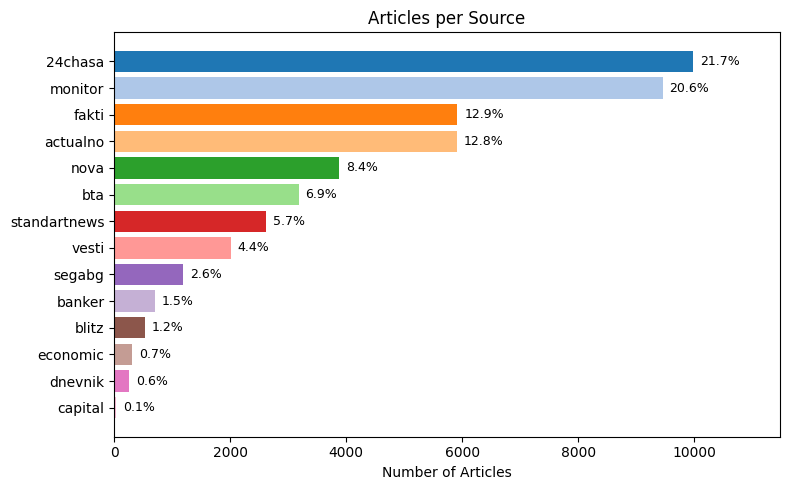

In [543]:
total = source_counts.sum()
pct = (source_counts / total * 100).round(1)
labels = [f"{pct[s]}%" for s in source_counts.index]
colors = plt.cm.tab20.colors[: len(source_counts)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    source_counts.index[::-1], source_counts.values[::-1], color=colors[::-1]
)
ax.set_title("Articles per Source")
ax.set_xlabel("Number of Articles")
ax.bar_label(bars, labels=labels[::-1], padding=5, fontsize=9)
ax.set_xlim(0, source_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 4. Temporal Coverage

Check the date range of collected articles and whether collection has been consistent over time.

In [544]:
print(f"Oldest  : {df['published_at_dt'].min()}")
print(f"Newest  : {df['published_at_dt'].max()}")
print(
    f"Days covered: {(df['published_at_dt'].max() - df['published_at_dt'].min()).days}"
)

Oldest  : 2026-03-10 04:05:33+00:00
Newest  : 2026-05-27 17:23:03.702777+00:00
Days covered: 78


In [545]:
earliest = (
    df.groupby("source")
    .agg(
        earliest_published=("published_at_dt", "min"),
        earliest_fetched=("fetched_at", "min"),
    )
    .sort_values("earliest_published")
)

earliest["published_at_dt"] = pd.to_datetime(earliest["earliest_published"]).dt.date
earliest["fetched_at"] = pd.to_datetime(earliest["earliest_fetched"]).dt.date
earliest["days_backfill"] = (
    pd.to_datetime(earliest["earliest_fetched"]).dt.tz_localize(None)
    - pd.to_datetime(earliest["earliest_published"]).dt.tz_localize(None)
).dt.days

print(earliest[["earliest_published", "earliest_fetched", "days_backfill"]].to_string())

                           earliest_published                  earliest_fetched  days_backfill
source                                                                                        
segabg              2026-03-10 04:05:33+00:00  2026-05-04T19:45:07.875620+00:00             55
nova                2026-04-19 21:02:57+00:00  2026-04-20T20:53:13.448140+00:00              0
24chasa             2026-04-20 11:34:00+00:00  2026-04-20T19:17:57.301914+00:00              0
actualno            2026-04-20 12:36:00+00:00  2026-04-20T19:20:20.997203+00:00              0
blitz               2026-04-20 15:25:00+00:00  2026-04-20T19:20:59.930288+00:00              0
fakti               2026-04-20 15:45:46+00:00  2026-04-20T19:17:32.119362+00:00              0
capital             2026-04-21 09:55:00+00:00  2026-04-22T19:23:07.081987+00:00              1
dnevnik             2026-04-22 13:23:00+00:00  2026-04-22T19:22:56.582424+00:00              0
economic            2026-05-03 09:00:10+00:00  202

### 4a. Segabg — RSS Backfill Investigation

In [546]:
segabg_df = df[df["source"] == "segabg"].copy()
segabg_df["fetched_at_dt"] = pd.to_datetime(segabg_df["fetched_at"])
segabg_df["fetch_round"] = segabg_df["fetched_at_dt"].dt.floor("2h")

per_fetch = segabg_df.groupby("fetch_round").size().sort_index()
print(f"Number of fetches: {len(per_fetch)}")
print(per_fetch.to_string())

Number of fetches: 169
fetch_round
2026-05-04 18:00:00+00:00    74
2026-05-04 20:00:00+00:00     2
2026-05-04 22:00:00+00:00     1
2026-05-05 02:00:00+00:00     1
2026-05-05 06:00:00+00:00    11
2026-05-05 10:00:00+00:00     8
2026-05-05 14:00:00+00:00    20
2026-05-05 16:00:00+00:00     7
2026-05-05 18:00:00+00:00     4
2026-05-05 20:00:00+00:00     4
2026-05-05 22:00:00+00:00     1
2026-05-06 02:00:00+00:00     3
2026-05-06 06:00:00+00:00     7
2026-05-06 10:00:00+00:00    11
2026-05-06 14:00:00+00:00     5
2026-05-06 16:00:00+00:00     8
2026-05-06 18:00:00+00:00     5
2026-05-06 20:00:00+00:00     1
2026-05-06 22:00:00+00:00     1
2026-05-07 06:00:00+00:00     7
2026-05-07 10:00:00+00:00     8
2026-05-07 14:00:00+00:00    14
2026-05-07 16:00:00+00:00     9
2026-05-07 22:00:00+00:00     2
2026-05-08 06:00:00+00:00    16
2026-05-08 08:00:00+00:00     7
2026-05-08 10:00:00+00:00     9
2026-05-08 12:00:00+00:00     8
2026-05-08 14:00:00+00:00     6
2026-05-08 16:00:00+00:00     5
2026-

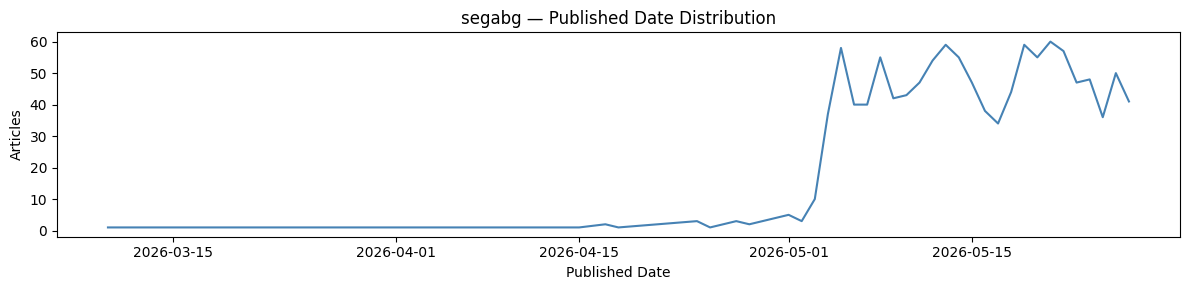

In [547]:
fig, ax = plt.subplots(figsize=(12, 3))
segabg_df["published_at_dt"].dt.date.value_counts().sort_index().plot(
    ax=ax, color="steelblue"
)
ax.set_title("segabg — Published Date Distribution")
ax.set_xlabel("Published Date")
ax.set_ylabel("Articles")
plt.tight_layout()
plt.show()

**Finding:** Segabg was added as a source on 2026-05-04. Its first fetch returned 74 articles in a single run, spanning back to 2026-03-10 — 55 days of backfill. All other sources showed 0 days backfill at first fetch. Subsequent segabg fetches return 1–20 articles, which is normal.

This is a one-time RSS backlog dump that inflates "days covered" from ~18 to 59 days and skews temporal analysis.

**Decision:** Drop segabg articles published before 2026-04-20 (the collection start date).

In [548]:
COLLECTION_START = pd.Timestamp("2026-04-20", tz="UTC")

backfill_mask = (df["source"] == "segabg") & (df["published_at_dt"] < COLLECTION_START)
print(
    f"Dropping {backfill_mask.sum()} segabg articles published before {COLLECTION_START.date()}"
)
df = df[~backfill_mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 7 segabg articles published before 2026-04-20
Remaining articles: 45925


In [549]:
print(f"Oldest  : {df['published_at_dt'].min()}")
print(f"Newest  : {df['published_at_dt'].max()}")
print(
    f"Days covered: {(df['published_at_dt'].max() - df['published_at_dt'].min()).days}"
)

Oldest  : 2026-04-19 21:02:57+00:00
Newest  : 2026-05-27 17:23:03.702777+00:00
Days covered: 37


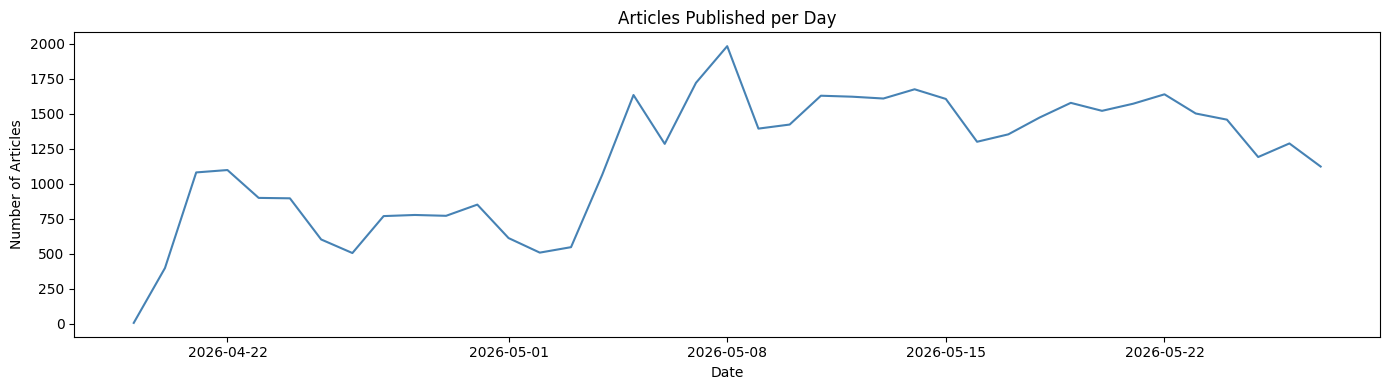

In [550]:
articles_per_day = df.groupby(df["published_at_dt"].dt.date).size()

fig, ax = plt.subplots(figsize=(14, 4))
articles_per_day.plot(ax=ax, color="steelblue")
ax.set_title("Articles Published per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
plt.tight_layout()
plt.show()

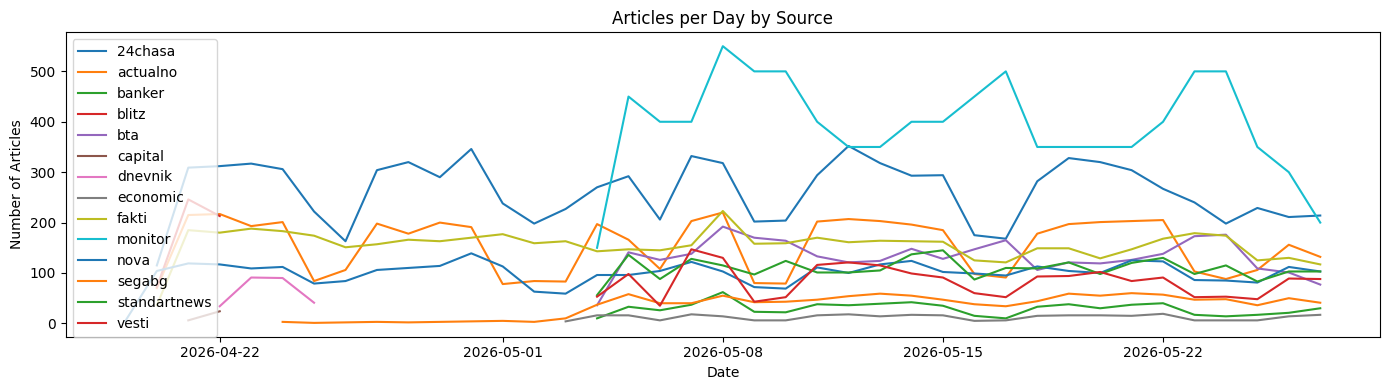

In [551]:
fig, ax = plt.subplots(figsize=(14, 4))
for source, group in df.groupby("source"):
    daily = group.groupby(group["published_at_dt"].dt.date).size()
    daily.plot(ax=ax, label=source)
ax.set_title("Articles per Day by Source")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Articles")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Missing & Empty Value Analysis

In [552]:
missing_summary = pd.DataFrame(
    {
        "null": df.isnull().sum(),
        "empty": (df == "").sum(),
        "whitespace_only": df.apply(
            lambda col: (col.str.strip() == "").sum() if col.dtype == "object" else 0
        )
        - (df == "").sum(),
        "total_missing": df.isnull().sum() + (df == "").sum(),
    }
)
missing_summary["%_missing"] = (missing_summary["total_missing"] / len(df) * 100).round(
    1
)
missing_summary

,null,empty,whitespace_only,total_missing,%_missing
source,0,0,0,0,0.0
title,0,0,0,0,0.0
url,0,0,0,0,0.0
published_at,0,0,0,0,0.0
summary,0,115,-115,115,0.3
full_text,0,569,-569,569,1.2
fetched_at,0,0,0,0,0.0
published_at_dt,0,0,0,0,0.0


In [553]:
print("Empty full_text per source:")
print(df[df["full_text"] == ""]["source"].value_counts())

Empty full_text per source:
source
blitz      530
capital     30
monitor      4
fakti        3
24chasa      1
bta          1
Name: count, dtype: int64


In [554]:
print("Empty summary per source:")
print(df[df["summary"] == ""]["source"].value_counts())

Empty summary per source:
source
vesti     93
segabg    22
Name: count, dtype: int64


In [555]:
empty_summary_sources = df[df["summary"] == ""]
empty_summary_sources.head()

,source,title,url,published_at,summary,full_text,fetched_at,published_at_dt
3749,segabg,ОБЯВА ЗА ТЪРГ С ТАЙНО НАДДАВАНЕ,https://www.segabg.com/category-imoti/obyava-z...,2026-04-24T11:11:30+00:00,,ДЪРЖАВЕН САТИРИЧЕН ТЕАТЪР „АЛЕКО КОНСТАНТИНОВ“...,2026-05-04T19:45:07.876283+00:00,2026-04-24 11:11:30+00:00
10581,vesti,Експлозия и пожар на южнокорейски кораб в Орму...,https://www.vesti.bg/sviat/eksploziia-i-pozhar...,2026-05-04T15:04:00+00:00,,"В ластите в Южна Корея съобщиха, че „експлозия...",2026-05-04T19:45:45.710489+00:00,2026-05-04 15:04:00+00:00
10710,vesti,Кремъл засилва сигурността около Путин на фона...,https://www.vesti.bg/sviat/kremyl-zasilva-sigu...,2026-05-04T10:51:00+00:00,,К ремъл значително е засилил личната охрана на...,2026-05-04T19:45:45.710719+00:00,2026-05-04 10:51:00+00:00
10838,vesti,Сериалът „Взимай парите и бягай“ за Ружа Игнат...,https://www.vesti.bg/lyubopitno/serialyt-vzima...,2026-05-04T13:13:00+00:00,,Н овият минисериал „Взимай парите и бягай“ (Ta...,2026-05-04T19:45:45.710547+00:00,2026-05-04 13:13:00+00:00
11152,vesti,"Българка падна от 20 метра в Гърция, в критичн...",https://www.vesti.bg/sviat/bylgarka-padna-ot-2...,2026-05-04T11:37:00+00:00,,"Б ългарка на 64 години е в критично състояние,...",2026-05-04T19:45:45.710665+00:00,2026-05-04 11:37:00+00:00


### 5a. Blitz & Capital — Empty `full_text`

In [556]:
# Confirm how many blitz/capital articles have content
for source in ["blitz", "capital"]:
    if source not in df["source"].values:
        print(f"{source}: not in dataset")
        continue
    total_s = len(df[df["source"] == source])
    non_empty = len(df[(df["source"] == source) & (df["full_text"] != "")])
    print(
        f"{source}: {total_s} total, {non_empty} with full_text ({total_s - non_empty} empty)"
    )

blitz: 531 total, 1 with full_text (530 empty)
capital: 30 total, 0 with full_text (30 empty)


In [557]:
# Inspect a blitz article HTML to understand why extraction failed
if "blitz" in df["source"].values:
    blitz_url = df[df["source"] == "blitz"]["url"].iloc[0]
    print(f"Testing URL: {blitz_url}")

    import requests

    HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; NewsBot/1.0)"}
    r = requests.get(blitz_url, timeout=10, headers=HEADERS)
    soup = BeautifulSoup(r.text, "html.parser")

    print(f"Status: {r.status_code} | Page length: {len(r.text)} chars")
    print()

    for tag in ["article", "main"]:
        found = soup.find(tag)
        print(f"<{tag}>: {'FOUND' if found else 'NOT FOUND'}")

    print()
    for div in soup.find_all("div", class_=True):
        classes = " ".join(div.get("class", []))
        text_len = len(div.get_text(strip=True))
        if text_len > 200:
            print(f"div.{classes[:60]}: {text_len} chars")

Testing URL: https://blitz.bg/voinite/tramp-posochi-denya-v-koyto-shte-podpishe-mir-s-iran_news1147877.html
Status: 200 | Page length: 155972 chars

<article>: FOUND
<main>: FOUND

div.container: 670 chars
div.header-middle: 206 chars
div.container: 405 chars
div.row: 405 chars
div.col-12 nav-container: 405 chars
div.container container-col: 9859 chars
div.left-col: 7472 chars
div.article-content: 5631 chars
div.row: 231 chars
div.section-body: 496 chars
div.more-from-topic-slider: 496 chars
div.section-body: 418 chars
div.row: 418 chars
div.theiaStickySidebar: 2387 chars
div.section-body: 365 chars
div.row: 365 chars
div.weather-widget: 784 chars
div.tab-content: 1207 chars
div.tab-pane fade show active: 676 chars
div.tab-pane fade show: 531 chars
div.container: 953 chars
div.row: 953 chars
div.col-12 col-md-7: 586 chars
div.d-flex flex-column: 586 chars


**Finding:** Blitz and Capital return valid HTTP 200 responses locally but GitHub Actions is blocked by those sites.
The one non-empty blitz article was likely fetched before the block kicked in.

**Decision:** 
- Dropping records from both `blitz` and `capital` sources and also the one record with empty `full_text` from `24chasa`
- Will keep records with empty `summary` for now, because their `full_text` column is not empty

In [558]:
sources = ["blitz", "capital"]
mask = df["source"].isin(sources)

print(f"Dropping {mask.sum()} articles from sources: {sources}")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 561 articles from sources: ['blitz', 'capital']
Remaining articles: 45364


In [559]:
mask = df["full_text"].isna() | (df["full_text"].str.strip() == "")

print(f"Dropping {mask.sum()} articles with empty full_text")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 9 articles with empty full_text
Remaining articles: 45355


## 6. Text Length Distribution

In [560]:
df["word_count"] = df["full_text"].fillna("").apply(lambda x: len(x.split()))
print(df["word_count"].describe().round(0))

count    45355.0
mean       381.0
std        495.0
min         13.0
25%        171.0
50%        271.0
75%        432.0
max      13773.0
Name: word_count, dtype: float64


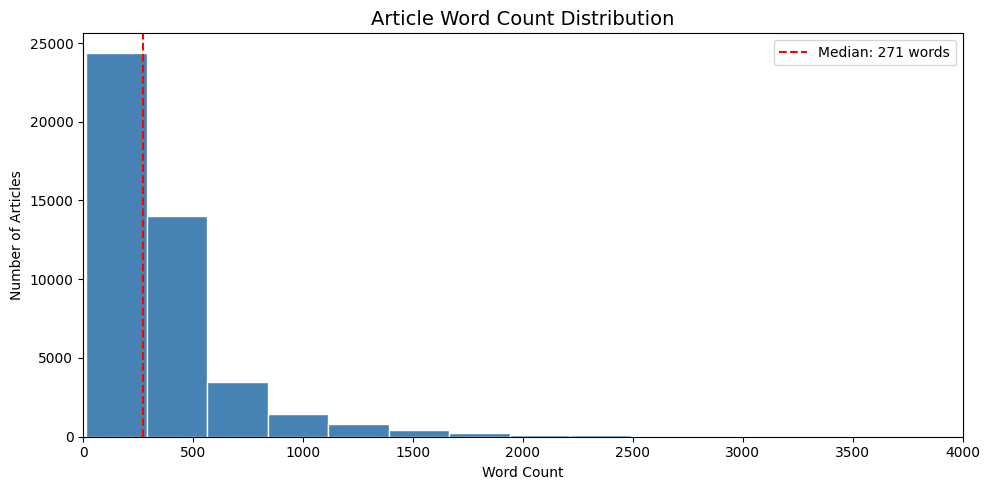

In [561]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["word_count"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Article Word Count Distribution", fontsize=14)
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Articles")
ax.axvline(
    df["word_count"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['word_count'].median():.0f} words",
)
ax.legend()
ax.set_xlim(0, 4000)
plt.tight_layout()
plt.show()

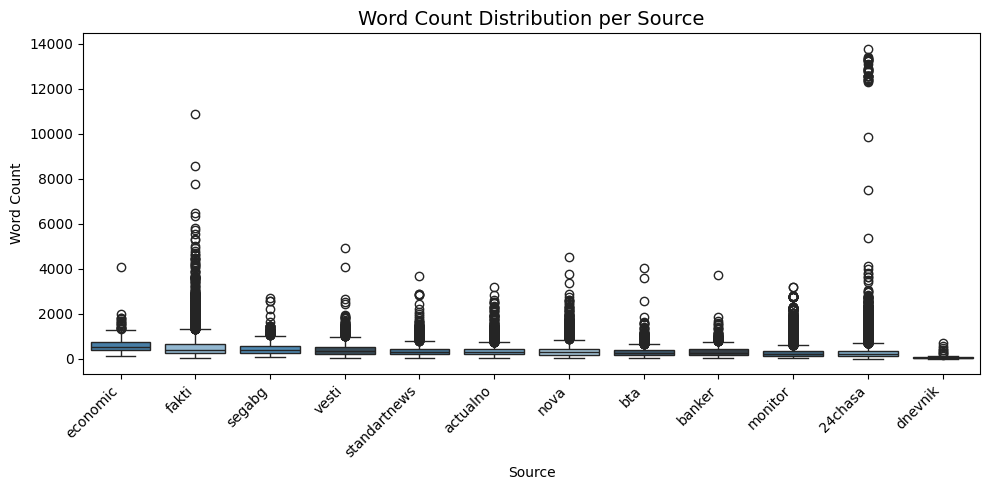

In [562]:
fig, ax = plt.subplots(figsize=(10, 5))
sources_ordered = (
    df.groupby("source")["word_count"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df,
    x="source",
    y="word_count",
    order=sources_ordered,
    palette="Blues_d",
    ax=ax,
    hue="source",
    legend=False,
)
ax.set_title("Word Count Distribution per Source", fontsize=14)
ax.set_xlabel("Source")
ax.set_ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [563]:
summary_stats = (
    df.groupby("source")["word_count"]
    .agg(["min", "max", "mean", "median", "count"])
    .round(0)
    .sort_values("median", ascending=False)
)
print(summary_stats)

              min    max   mean  median  count
source                                        
economic      130   4092  605.0   524.0    308
fakti          47  10868  579.0   386.0   5912
segabg         83   2696  452.0   371.0   1180
vesti          48   4945  415.0   327.0   2006
standartnews   38   3687  381.0   317.0   2610
actualno       39   3203  370.0   304.0   5902
nova           15   4502  417.0   295.0   3875
bta            36   4016  309.0   263.0   3178
banker         31   3714  344.0   258.0    705
monitor        35   3173  297.0   219.0   9446
24chasa        13  13773  349.0   213.0   9977
dnevnik        13    701   55.0    23.0    256


## 10. Duplicate Detection

### 10a. URL-based duplicates

Two types of duplicates to check:
- **Same-source duplicates**: same article fetched in multiple 2-hour collection windows
- **Near-duplicates**: same URL with slightly different content (edited articles)

In [564]:
url_counts = df["url"].value_counts()
duplicate_urls = url_counts[url_counts > 1]
excess = (url_counts - 1).clip(lower=0).sum()

print(f"Total articles  : {len(df)}")
print(f"Unique URLs     : {df['url'].nunique()}")
print(f"Duplicate URLs  : {len(duplicate_urls)}")
print(f"Excess rows     : {excess} ({excess / len(df) * 100:.1f}% of total) -> rows that are duplicates")

Total articles  : 45355
Unique URLs     : 37853
Duplicate URLs  : 2265
Excess rows     : 7502 (16.5% of total) -> rows that are duplicates


In [565]:
duplicates_df = df[df["url"].isin(duplicate_urls.index)].copy()

print("Duplicate articles per source:")
print(duplicates_df["source"].value_counts())

Duplicate articles per source:
source
monitor         9278
segabg           251
fakti             86
24chasa           79
bta               24
actualno          21
nova              16
standartnews       8
dnevnik            2
vesti              2
Name: count, dtype: int64


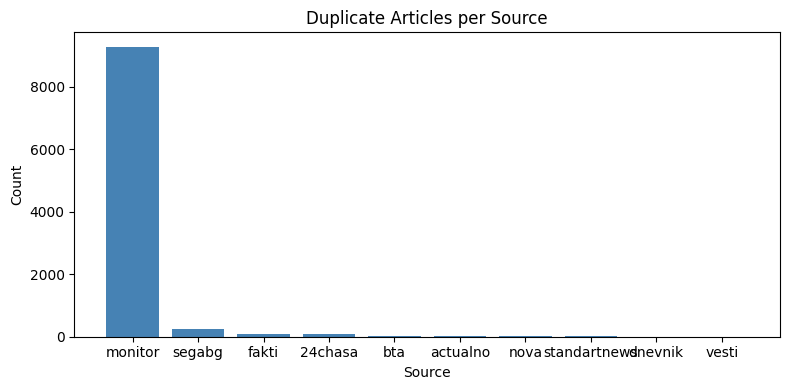

In [566]:
fig, ax = plt.subplots(figsize=(8, 4))

dup_per_source = duplicates_df["source"].value_counts()
ax.bar(dup_per_source.index, dup_per_source.values, color="steelblue")
ax.set_title("Duplicate Articles per Source")
ax.set_xlabel("Source")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

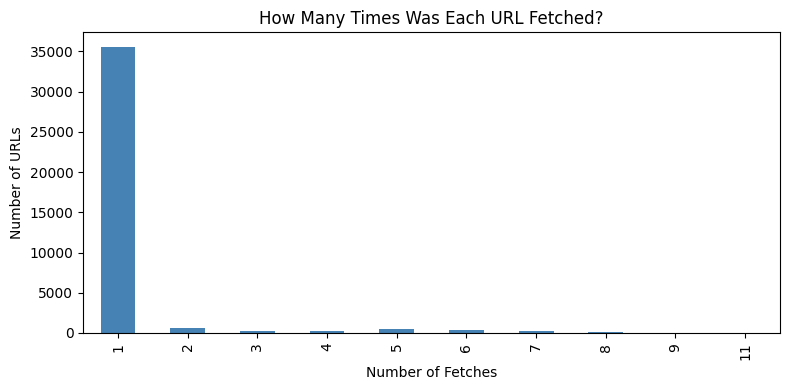

In [567]:
fig, ax = plt.subplots(figsize=(8, 4))

url_counts.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("How Many Times Was Each URL Fetched?")
ax.set_xlabel("Number of Fetches")
ax.set_ylabel("Number of URLs")

plt.tight_layout()
plt.show()

In [568]:
# Investigate: are duplicated articles identical or edited between fetches?
sample_dup_url = duplicate_urls.index[0]
versions = df[df["url"] == sample_dup_url][
    ["source", "title", "fetched_at", "full_text"]
]
print(f"URL: {sample_dup_url}")
print(f"Fetched {len(versions)} times")
print()
for i, (_, row) in enumerate(versions.iterrows()):
    print(f"Version {i+1} — fetched at {row['fetched_at']}")
    print(f"Text preview: {str(row['full_text'])[:300]}")
    print()

URL: https://www.segabg.com/category-sport/purva-liga-xxxiii-krug-rezultati-i-klasirane-video-reportazhi-0
Fetched 11 times

Version 1 — fetched at 2026-05-05T19:25:40.174230+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Диема спорт)
9 май (събота)
"Левски" - "Лудогорец" 18:45 ч.
(по Диема спорт)
КЛАСИРАНЕ | ||||||
| М | П | Р | З | ГР | Т | |
1. "Левски" |
32 |
24 |
4 |
4 |
68:23 |
76 |
2. "ЦСКА 1948" |
32 |
19 |
5 |
8 |
52:33 |
62 |
3. "Лудогорец" |
32 |
17

Version 2 — fetched at 2026-05-06T19:50:18.277093+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Диема спорт)
9 май (събота)
"Левски" - "Лудогорец" 18:45 ч.
(по Диема спорт)
КЛАСИРАНЕ | ||||||
| М | П | Р | З | ГР | Т | |
1. "Левски" |
32 |
24 |
4 |
4 |
68:23 |
76 |
2. "ЦСКА 1948" |
32 |
19 |
5 |
8 |
52:33 |
62 |
3. "Лудогорец" |
32 |
17

Version 3 — fetched at 2026-05-06T17:44:10.819265+00:00
Text preview: Първа група
8 май (петък)
"ЦСКА 1948" - ЦСКА 20:00 ч.
(по Дие

Duplicates are concentrated in monitor, with minor contributions from other sources.

Inspection of a sample URL fetched many times shows identical full_text across all versions — these are not edited articles but the same article caught in multiple 2-hour collection windows before dropping off the RSS feed.

Decision: Deduplicate by URL, keeping the latest fetched version per URL.

Investigating monitor problem with duplications

In [569]:
monitor_urls = df[df["source"] == "monitor"]["url"]
monitor_dup_urls = monitor_urls[monitor_urls.duplicated(keep=False)]

print(f"Total monitor articles     : {len(monitor_urls)}")
print(f"Unique monitor URLs        : {monitor_urls.nunique()}")
print(f"After dedup (kept)         : {monitor_urls.nunique()}")
print(f"Rows to drop from monitor  : {len(monitor_urls) - monitor_urls.nunique()}")

Total monitor articles     : 9446
Unique monitor URLs        : 2207
After dedup (kept)         : 2207
Rows to drop from monitor  : 7239


In [570]:
monitor_unique = df[df["source"] == "monitor"].drop_duplicates(subset="url")
print(f"Unique articles : {len(monitor_unique)}")
print(
    f"Date range      : {monitor_unique['published_at_dt'].min().date()} → {monitor_unique['published_at_dt'].max().date()}"
)
print(f"Median words    : {monitor_unique['word_count'].median()}")
print("\nPublished per day:")
print(monitor_unique["published_at_dt"].dt.date.value_counts().sort_index().to_string())

Unique articles : 2207
Date range      : 2026-05-04 → 2026-05-27
Median words    : 216.0

Published per day:
published_at_dt
2026-05-04     52
2026-05-05    111
2026-05-06     80
2026-05-07     93
2026-05-08    123
2026-05-09     99
2026-05-10     62
2026-05-11    103
2026-05-12    100
2026-05-13     92
2026-05-14     88
2026-05-15     91
2026-05-16     71
2026-05-17     71
2026-05-18    113
2026-05-19     96
2026-05-20     97
2026-05-21    103
2026-05-22    109
2026-05-23     92
2026-05-24     80
2026-05-25    110
2026-05-26     94
2026-05-27     77


In [571]:
before = len(df)
df = (
    df.sort_values("fetched_at", ascending=False)
    .drop_duplicates(subset="url", keep="first")
    .reset_index(drop=True)
)

pct = (before - len(df)) / before * 100

print(f"Dropped {before - len(df)} duplicate rows -> {before - len(df)} ({pct:.1f}% of total)")
print(f"Remaining articles: {len(df)}")

Dropped 7502 duplicate rows -> 7502 (16.5% of total)
Remaining articles: 37853


### 10b. Content-based near-duplicate detection

Following the newsLens approach (Laban & Hearst, 2017): some sources publish multiple 
versions of the same article with minor changes — updated headline, added sentence, 
corrected fact. These have different URLs and survive URL-based deduplication but are 
semantically identical.

Method:
1. Group articles by source + 3-day time window
2. Compute TF-IDF vectors per article within each group
3. Compute pairwise cosine similarity
4. Articles above similarity threshold → near-duplicates → keep most recent


In [572]:
# Assign 3-day time windows per article
df["window"] = df["published_at_dt"].dt.tz_localize(None).dt.to_period("3D")

print(f"Articles after URL deduplication: {len(df)}")
print(f"Unique source+window groups (3 days): {df.groupby(['source', 'window']).ngroups}")

Articles after URL deduplication: 37853
Unique source+window groups (3 days): 335


In [573]:
# Analyze how many near-duplicate pairs exist at different thresholds
# This helps pick the right threshold before removing anything

thresholds = [0.80, 0.85, 0.90, 0.95]
threshold_counts = {t: 0 for t in thresholds}
total_pairs_checked = 0

for (source, window), group in df.groupby(["source", "window"]):
    if len(group) < 2:
        continue

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    n = len(group)
    total_pairs_checked += n * (n - 1) // 2

    # Check upper triangle only (avoid counting pairs twice)
    for i in range(n):
        for j in range(i + 1, n):
            sim = sim_matrix[i, j]
            for t in thresholds:
                if sim >= t:
                    threshold_counts[t] += 1

print(f"Total pairs checked: {total_pairs_checked:,}")
print()
for t, count in threshold_counts.items():
    pct = count / total_pairs_checked * 100
    print(f"Threshold {t}: {count:>6} near-duplicate pairs ({pct:.2f}% of all pairs)")

Total pairs checked: 3,142,842

Threshold 0.8:   4910 near-duplicate pairs (0.16% of all pairs)
Threshold 0.85:   3161 near-duplicate pairs (0.10% of all pairs)
Threshold 0.9:   1972 near-duplicate pairs (0.06% of all pairs)
Threshold 0.95:   1561 near-duplicate pairs (0.05% of all pairs)


In [574]:
# Inspect a few pairs above the chosen threshold to validate it makes sense
INSPECT_THRESHOLD = 0.5

print(f"Sample near-duplicate pairs at threshold >= {INSPECT_THRESHOLD}:\n")

samples_shown = 0
for (source, week), group in df.groupby(["source", "window"]):
    if len(group) < 2 or samples_shown >= 5:
        break

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    rows = group.reset_index(drop=True)
    n = len(rows)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= INSPECT_THRESHOLD and samples_shown < 5:
                print(
                    f"Source: {source} | Week: {week} | Similarity: {sim_matrix[i,j]:.3f}"
                )
                print(f"  Article A: {rows.iloc[i]['title']}")
                print(f"  Article B: {rows.iloc[i]['url']}")
                print(f"  Article B: {rows.iloc[j]['title']}")
                print(f"  Article B: {rows.iloc[j]['url']}")
                print(f"  Date A: {rows.iloc[i]['published_at_dt'].date()}")
                print(f"  Date B: {rows.iloc[j]['published_at_dt'].date()}")
                print()
                samples_shown += 1

Sample near-duplicate pairs at threshold >= 0.5:

Source: 24chasa | Week: 2026-04-20 | Similarity: 0.562
  Article A: Мадяр пак призова унгарския президент Шуйок и висши съдии да подадат оставка
  Article B: https://www.24chasa.bg/mezhdunarodni/article/22702665
  Article B: Мадяр номинира Анита Орбан за външен министър на Унгария
  Article B: https://www.24chasa.bg/mezhdunarodni/article/22701777
  Date A: 2026-04-20
  Date B: 2026-04-20

Source: 24chasa | Week: 2026-04-20 | Similarity: 0.596
  Article A: Румънските социалдемократи оттеглиха подкрепата си към премиера Илие Боложан
  Article B: https://www.24chasa.bg/mezhdunarodni/article/22702997
  Article B: Премиерът на Румъния: Ще продължа да изпълнявам мандата си
  Article B: https://www.24chasa.bg/mezhdunarodni/article/22703866
  Date A: 2026-04-20
  Date B: 2026-04-20

Source: 24chasa | Week: 2026-04-20 | Similarity: 0.877
  Article A: Олимпийският шампион Семен Новиков ще се бори за европейска титла
  Article B: https://www.24cha

In [575]:
# Apply near-duplicate removal at chosen threshold
# Keep most recent article in each duplicate pair
CHOSEN_THRESHOLD = 0.95

rows_to_drop = set()

for (source, week), group in df.groupby(["source", "window"]):
    if len(group) < 2:
        continue

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    rows = group.reset_index()  # keep original index
    n = len(rows)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= CHOSEN_THRESHOLD:
                # Drop the older article, keep the more recent one
                date_i = rows.iloc[i]["published_at_dt"]
                date_j = rows.iloc[j]["published_at_dt"]
                drop_idx = (
                    rows.iloc[i]["index"] if date_i <= date_j else rows.iloc[j]["index"]
                )
                rows_to_drop.add(drop_idx)

print(f"Near-duplicate articles to drop : {len(rows_to_drop)}")
print(f"Articles before                 : {len(df)}")

df = df.drop(index=rows_to_drop).reset_index(drop=True)
print(f"Articles after                  : {len(df)}")
print(
    f"Reduction                       : {len(rows_to_drop) / (len(df) + len(rows_to_drop)) * 100:.1f}%"
)

Near-duplicate articles to drop : 647
Articles before                 : 37853
Articles after                  : 37206
Reduction                       : 1.7%


## 11. Storing cleaned data in `.parquet` file

In [576]:
out_path = "../data/processed/articles_clean_notebook.parquet"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_parquet(out_path, index=False)
print(f"Saved {len(df)} articles → {out_path}")

Saved 37206 articles → ../data/processed/articles_clean_notebook.parquet


## Summary

**What was done:**
- Loaded all raw JSON articles from date-partitioned folders into a single DataFrame
- Audited the schema, data types, and basic structure
- Analyzed the distribution of articles across sources and visualized temporal coverage
- Identified and removed a historical RSS backfill from one source (`segabg`) that predated the actual collection start — keeping only articles published after collection began
- Detected sources (`blitz`, `capital`) whose article content could not be fetched due to bot-blocking; dropped all records from those sources along with any remaining articles with empty `full_text`
- Analyzed text length (word count) distribution overall and per source
- Detected URL-level duplicates caused by the same article appearing in multiple 2-hour collection windows; verified the content was identical across versions, then deduplicated by keeping the latest fetched copy per URL

**Result:** A deduplicated DataFrame containing only articles with non-empty full text, published within the active collection window, saved to `data/processed/articles_clean.parquet` and ready for cleaning and further analysis.